# Training our GMM (POC)

In [2]:
from pathlib import Path
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, pearsonr

In [ ]:
PROJECT_ROOT = Path("/path/Sample-Adaptive-Diffusion-Steps")


BSDS_TRAIN = PROJECT_ROOT / "data" / "BSDS300" / "images" / "train"
BSDS_TEST  = PROJECT_ROOT / "data" / "BSDS300" / "images" / "test"

IMAGENET_SUBSET = PROJECT_ROOT / "data" / "imagenet_subset"

train_dirs = [BSDS_TRAIN, BSDS_TEST, IMAGENET_SUBSET]

# train_dirs = [OOD_DIR, BEDROOM_DIR, CHURCH_DIR]

for d in train_dirs:
    print(d, d.exists())

/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train True
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/test True
/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/imagenet_subset True


In [4]:
train_image_paths = []

extensions = ["*.jpg", "*.jpeg", "*.png", "*.JPEG", "*.JPG", "*.PNG"]

for d in train_dirs:
    for ext in extensions:
        train_image_paths.extend(list(d.rglob(ext)))

print("num training images:", len(train_image_paths))
print(train_image_paths[:5])

num training images: 3300
[PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/176019.jpg'), PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/112082.jpg'), PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/108041.jpg'), PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/187039.jpg'), PosixPath('/projectnb/cs505am/students/hbbeth/DDIM/Sample-Adaptive-Diffusion-Steps/data/BSDS300/images/train/260081.jpg')]


In [5]:
def load_grayscale_image(path, image_size=64):
    img = Image.open(path).convert("L")  # grayscale
    img = img.resize((image_size, image_size))
    arr = np.array(img).astype(np.float32) / 255.0
    return arr

def extract_patches(img, patch_size=8, stride=4):
    patches = []
    H, W = img.shape
    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = img[i:i+patch_size, j:j+patch_size].reshape(-1)
            patches.append(patch)
    return np.array(patches, dtype=np.float32)

In [6]:
all_patches = []

# for proof of concept, cap number of images if needed
max_train_images = len(train_image_paths)

sampled_paths = random.sample(train_image_paths, max_train_images)

for path in sampled_paths:
    img = load_grayscale_image(path, image_size=64)
    patches = extract_patches(img, patch_size=8, stride=4)
    all_patches.append(patches)

all_patches = np.concatenate(all_patches, axis=0)

print("patch matrix shape:", all_patches.shape)

patch matrix shape: (742500, 64)


In [7]:
scaler = StandardScaler()
all_patches_scaled = scaler.fit_transform(all_patches)

print(all_patches_scaled.shape)

(742500, 64)


In [9]:
gmm = GaussianMixture(
    n_components=100,
    covariance_type="diag",
    reg_covar=1e-5,
    random_state=42,
    max_iter=200,
    verbose=1
)

gmm.fit(all_patches_scaled.astype("float64"))
print("GMM trained.")

Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
  Iteration 60
  Iteration 70
  Iteration 80
  Iteration 90
  Iteration 100
  Iteration 110
Initialization converged.
GMM trained.


In [10]:
import joblib

joblib.dump(gmm, "gmm_100_diag_reg1e-5_200iter.pkl")
joblib.dump(scaler, "patch_scaler_200iter_gmm.pkl")

['patch_scaler_200iter_gmm.pkl']

## Testing

In [ ]:

def image_complexity_nll(path, image_size=64, patch_size=8, stride=4):
    img = load_grayscale_image(path, image_size=image_size)
    patches = extract_patches(img, patch_size=patch_size, stride=stride)
    patches_scaled = scaler.transform(patches)

    log_probs = gmm.score_samples(patches_scaled)
    nll = -log_probs

    top_k = max(1, int(0.1 * len(nll)))
    sorted_nll = np.sort(nll)

    return {
        "mean_nll": float(np.mean(nll)),
        "std_nll": float(np.std(nll)),
        "max_nll": float(np.max(nll)),
        "median_nll": float(np.median(nll)),
        "p90_nll": float(np.percentile(nll, 90)),
        "top10_mean_nll": float(np.mean(sorted_nll[-top_k:])),
    }

In [ ]:
# Use blurred/degraded images from one DDRM run, not clean orig_*.png
# Pick any one run folder; y0_*.png should correspond to the degraded observation.
DDR_ROOT = PROJECT_ROOT / "external" / "ddrm"
REF_RUN_DIR = DDR_ROOT / "exp" / "image_samples" / "run_k50_100imgs"

eval_image_paths = sorted(list(REF_RUN_DIR.glob("y0_*.png")))

print("num eval degraded images:", len(eval_image_paths))
for p in eval_image_paths:
    print(p.name)

num eval degraded images: 100
y0_0.png
y0_1.png
y0_10.png
y0_11.png
y0_12.png
y0_13.png
y0_14.png
y0_15.png
y0_16.png
y0_17.png
y0_18.png
y0_19.png
y0_2.png
y0_20.png
y0_21.png
y0_22.png
y0_23.png
y0_24.png
y0_25.png
y0_26.png
y0_27.png
y0_28.png
y0_29.png
y0_3.png
y0_30.png
y0_31.png
y0_32.png
y0_33.png
y0_34.png
y0_35.png
y0_36.png
y0_37.png
y0_38.png
y0_39.png
y0_4.png
y0_40.png
y0_41.png
y0_42.png
y0_43.png
y0_44.png
y0_45.png
y0_46.png
y0_47.png
y0_48.png
y0_49.png
y0_5.png
y0_50.png
y0_51.png
y0_52.png
y0_53.png
y0_54.png
y0_55.png
y0_56.png
y0_57.png
y0_58.png
y0_59.png
y0_6.png
y0_60.png
y0_61.png
y0_62.png
y0_63.png
y0_64.png
y0_65.png
y0_66.png
y0_67.png
y0_68.png
y0_69.png
y0_7.png
y0_70.png
y0_71.png
y0_72.png
y0_73.png
y0_74.png
y0_75.png
y0_76.png
y0_77.png
y0_78.png
y0_79.png
y0_8.png
y0_80.png
y0_81.png
y0_82.png
y0_83.png
y0_84.png
y0_85.png
y0_86.png
y0_87.png
y0_88.png
y0_89.png
y0_9.png
y0_90.png
y0_91.png
y0_92.png
y0_93.png
y0_94.png
y0_95.png
y0_96.png
y0_97.png


In [ ]:

kstar_labels = {
    "orig_0.png": 50,
    "orig_1.png": 100,
    "orig_2.png": 30,
    "orig_3.png": 100,
    "orig_4.png": 100,
    "orig_5.png": 30,
    "orig_6.png": 100,
    "orig_7.png": 50,
    "orig_8.png": 100,
    "orig_9.png": 100,
    "orig_10.png": 50,
    "orig_11.png": 100,
    "orig_12.png": 10,
    "orig_13.png": 50,
    "orig_14.png": 50,
    "orig_15.png": 100,
    "orig_16.png": 100,
    "orig_17.png": 100,
    "orig_18.png": 50,
    "orig_19.png": 30,
    "orig_20.png": 100,
    "orig_21.png": 50,
    "orig_22.png": 20,
    "orig_23.png": 10,
    "orig_24.png": 30,
    "orig_25.png": 5,
    "orig_26.png": 100,
    "orig_27.png": 100,
    "orig_28.png": 100,
    "orig_29.png": 100,
    "orig_30.png": 20,
    "orig_31.png": 20,
    "orig_32.png": 100,
    "orig_33.png": 100,
    "orig_34.png": 100,
    "orig_35.png": 50,
    "orig_36.png": 30,
    "orig_37.png": 10,
    "orig_38.png": 100,
    "orig_39.png": 100,
    "orig_40.png": 100,
    "orig_41.png": 50,
    "orig_42.png": 50,
    "orig_43.png": 100,
    "orig_44.png": 100,
    "orig_45.png": 20,
    "orig_46.png": 100,
    "orig_47.png": 50,
    "orig_48.png": 100,
    "orig_49.png": 100,
    "orig_50.png": 100,
    "orig_51.png": 100,
    "orig_52.png": 10,
    "orig_53.png": 100,
    "orig_54.png": 100,
    "orig_55.png": 10,
    "orig_56.png": 30,
    "orig_57.png": 50,
    "orig_58.png": 100,
    "orig_59.png": 30,
    "orig_60.png": 10,
    "orig_61.png": 20,
    "orig_62.png": 100,
    "orig_63.png": 30,
    "orig_64.png": 30,
    "orig_65.png": 50,
    "orig_66.png": 20,
    "orig_67.png": 100,
    "orig_68.png": 30,
    "orig_69.png": 5,
    "orig_70.png": 30,
    "orig_71.png": 100,
    "orig_72.png": 50,
    "orig_73.png": 50,
    "orig_74.png": 100,
    "orig_75.png": 30,
    "orig_76.png": 100,
    "orig_77.png": 50,
    "orig_78.png": 100,
    "orig_79.png": 100,
    "orig_80.png": 100,
    "orig_81.png": 100,
    "orig_82.png": 100,
    "orig_83.png": 50,
    "orig_84.png": 100,
    "orig_85.png": 100,
    "orig_86.png": 50,
    "orig_87.png": 100,
    "orig_88.png": 100,
    "orig_89.png": 100,
    "orig_90.png": 50,
    "orig_91.png": 20,
    "orig_92.png": 100,
    "orig_93.png": 30,
    "orig_94.png": 100,
    "orig_95.png": 100,
    "orig_96.png": 100,
    "orig_97.png": 20,
    "orig_98.png": 30,
    "orig_99.png": 100,
}

In [ ]:
import re

def extract_image_idx(filename):
    # works for y0_0.png, orig_3.png, etc.
    m = re.search(r"_(\d+)\.png$", filename)
    if m is None:
        raise ValueError(f"Could not extract image index from {filename}")
    return int(m.group(1))

rows = []

for path in eval_image_paths:
    idx = extract_image_idx(path.name)
    orig_name = f"orig_{idx}.png"   # maps degraded image back to your k* labels

    stats = image_complexity_nll(path, image_size=64, patch_size=8, stride=4)

    rows.append({
        "image": path.name,          # now this will be y0_*.png
        "image_idx": idx,
        "mean_nll": stats["mean_nll"],
        "std_nll": stats["std_nll"],
        "max_nll": stats["max_nll"],
        "median_nll": stats["median_nll"],
        "p90_nll": stats["p90_nll"],
        "top10_mean_nll": stats["top10_mean_nll"],
        "kstar": kstar_labels[orig_name],
    })

rows

[{'image': 'y0_0.png',
  'image_idx': 0,
  'mean_nll': -46.613789403817606,
  'std_nll': 34.64855141795942,
  'max_nll': 39.376897138490115,
  'median_nll': -40.68374742795916,
  'p90_nll': 2.2596294735079545,
  'top10_mean_nll': 11.552006531401124,
  'kstar': 50},
 {'image': 'y0_1.png',
  'image_idx': 1,
  'mean_nll': -11.380457923399105,
  'std_nll': 35.65179730352485,
  'max_nll': 48.637014397320094,
  'median_nll': -6.548115660944397,
  'p90_nll': 32.08790743826896,
  'top10_mean_nll': 40.15301157007262,
  'kstar': 100},
 {'image': 'y0_10.png',
  'image_idx': 10,
  'mean_nll': -17.518912774994277,
  'std_nll': 24.171114759458565,
  'max_nll': 60.99372992460056,
  'median_nll': -17.833046986112862,
  'p90_nll': 13.020634715248535,
  'top10_mean_nll': 30.5529751520001,
  'kstar': 50},
 {'image': 'y0_11.png',
  'image_idx': 11,
  'mean_nll': -6.790635589413048,
  'std_nll': 26.14463358921296,
  'max_nll': 45.442767708126766,
  'median_nll': -3.956491156910345,
  'p90_nll': 23.54574326

In [40]:
import pandas as pd

df = pd.DataFrame(rows).sort_values("image").reset_index(drop=True)
df.to_csv("gmm_results_3k_imgs.csv", index=False)
print("saved gmm_results_3k_imgs.csv")
df

saved gmm_results_3k_imgs.csv


,image,image_idx,mean_nll,std_nll,max_nll,median_nll,p90_nll,top10_mean_nll,kstar
0,y0_0.png,0,-46.613789,34.648551,39.376897,-40.683747,2.259629,11.552007,50
1,y0_1.png,1,-11.380458,35.651797,48.637014,-6.548116,32.087907,40.153012,100
2,y0_10.png,10,-17.518913,24.171115,60.993730,-17.833047,13.020635,30.552975,50
3,y0_11.png,11,-6.790636,26.144634,45.442768,-3.956491,23.545743,31.366422,100
4,y0_12.png,12,-4.817624,24.971768,46.499150,-4.119651,29.838728,35.442251,10
...,...,...,...,...,...,...,...,...,...
95,y0_95.png,95,12.209603,29.114948,51.903570,18.733892,41.220565,45.477942,100
96,y0_96.png,96,-11.368919,39.448143,58.918661,-4.385570,32.891973,42.346695,100
97,y0_97.png,97,-6.846171,32.177846,54.314826,-0.810718,32.154104,42.303247,20
98,y0_98.png,98,-18.275196,31.239668,51.077826,-14.165839,17.291576,26.900749,30


In [41]:

print(df.shape)
df.head()

(100, 9)


,image,image_idx,mean_nll,std_nll,max_nll,median_nll,p90_nll,top10_mean_nll,kstar
0,y0_0.png,0,-46.613789,34.648551,39.376897,-40.683747,2.259629,11.552007,50
1,y0_1.png,1,-11.380458,35.651797,48.637014,-6.548116,32.087907,40.153012,100
2,y0_10.png,10,-17.518913,24.171115,60.993730,-17.833047,13.020635,30.552975,50
3,y0_11.png,11,-6.790636,26.144634,45.442768,-3.956491,23.545743,31.366422,100
4,y0_12.png,12,-4.817624,24.971768,46.499150,-4.119651,29.838728,35.442251,10


In [42]:
from scipy.stats import pearsonr, spearmanr

features = ["mean_nll", "std_nll", "max_nll", "median_nll", "p90_nll", "top10_mean_nll"]

for feat in features:
    x = df[feat].values
    y = df["kstar"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    print(f"{feat} vs k*")
    print(f"  Pearson:  r={pearson_r:.4f}, p={pearson_p:.4f}")
    print(f"  Spearman: r={spearman_r:.4f}, p={spearman_p:.4f}")
    print()

mean_nll vs k*
  Pearson:  r=0.3222, p=0.0011
  Spearman: r=0.3113, p=0.0016

std_nll vs k*
  Pearson:  r=0.0588, p=0.5612
  Spearman: r=0.0728, p=0.4716

max_nll vs k*
  Pearson:  r=0.3073, p=0.0019
  Spearman: r=0.2533, p=0.0110

median_nll vs k*
  Pearson:  r=0.3358, p=0.0006
  Spearman: r=0.3544, p=0.0003

p90_nll vs k*
  Pearson:  r=0.3704, p=0.0001
  Spearman: r=0.3379, p=0.0006

top10_mean_nll vs k*
  Pearson:  r=0.3685, p=0.0002
  Spearman: r=0.3329, p=0.0007



In [43]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

features = ["mean_nll", "std_nll", "max_nll", "median_nll", "p90_nll", "top10_mean_nll"]

rows = []

for feat in features:
    x = df[feat].values
    y = df["kstar"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    rows.append({
        "feature": feat,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

corr_df = pd.DataFrame(rows)
corr_df

,feature,pearson_r,pearson_p,spearman_r,spearman_p
0,mean_nll,0.322215,0.001078,0.311329,0.001617
1,std_nll,0.058797,0.561186,0.072807,0.471601
2,max_nll,0.307296,0.001871,0.253280,0.011004
3,median_nll,0.335758,0.000638,0.354393,0.000297
4,p90_nll,0.370425,0.000149,0.337942,0.000585
5,top10_mean_nll,0.368547,0.000161,0.332893,0.000714


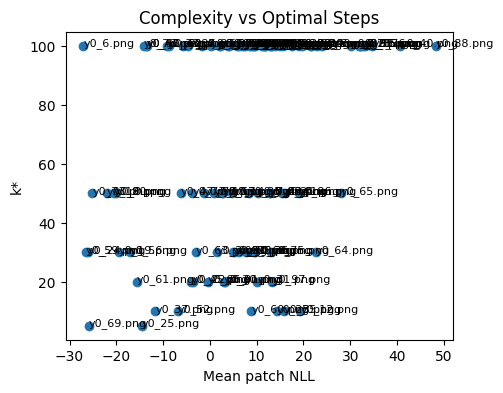

In [17]:
plt.figure(figsize=(5,4))
plt.scatter(df["mean_nll"], df["kstar"])
for _, row in df.iterrows():
    plt.annotate(row["image"], (row["mean_nll"], row["kstar"]), fontsize=8)
plt.xlabel("Mean patch NLL")
plt.ylabel("k*")
plt.title("Complexity vs Optimal Steps")
plt.show()

### Saved GMM with 100 components, ~500 iterations, regularization 1e-5

In [16]:
import joblib

gmm = joblib.load("./checkpoints/gmm_100_500iter_reg1-5/gmm_100_diag_reg1e-5.pkl")
scaler = joblib.load("./checkpoints/gmm_100_500iter_reg1-5/patch_scaler.pkl")

In [7]:
print("Components:", gmm.n_components)

Components: 100


In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("/path/Sample-Adaptive-Diffusion-Steps")

DDR_ROOT = PROJECT_ROOT / "external" / "ddrm"
REF_RUN_DIR = DDR_ROOT / "exp" / "image_samples" / "IMAGENET 100 IMAGES" / "run_k50_100imgs"

eval_image_paths = sorted(list(REF_RUN_DIR.glob("y0_*.png")))

print("num eval degraded images:", len(eval_image_paths))
for p in eval_image_paths:
    print(p.name)

num eval degraded images: 100
y0_0.png
y0_1.png
y0_10.png
y0_11.png
y0_12.png
y0_13.png
y0_14.png
y0_15.png
y0_16.png
y0_17.png
y0_18.png
y0_19.png
y0_2.png
y0_20.png
y0_21.png
y0_22.png
y0_23.png
y0_24.png
y0_25.png
y0_26.png
y0_27.png
y0_28.png
y0_29.png
y0_3.png
y0_30.png
y0_31.png
y0_32.png
y0_33.png
y0_34.png
y0_35.png
y0_36.png
y0_37.png
y0_38.png
y0_39.png
y0_4.png
y0_40.png
y0_41.png
y0_42.png
y0_43.png
y0_44.png
y0_45.png
y0_46.png
y0_47.png
y0_48.png
y0_49.png
y0_5.png
y0_50.png
y0_51.png
y0_52.png
y0_53.png
y0_54.png
y0_55.png
y0_56.png
y0_57.png
y0_58.png
y0_59.png
y0_6.png
y0_60.png
y0_61.png
y0_62.png
y0_63.png
y0_64.png
y0_65.png
y0_66.png
y0_67.png
y0_68.png
y0_69.png
y0_7.png
y0_70.png
y0_71.png
y0_72.png
y0_73.png
y0_74.png
y0_75.png
y0_76.png
y0_77.png
y0_78.png
y0_79.png
y0_8.png
y0_80.png
y0_81.png
y0_82.png
y0_83.png
y0_84.png
y0_85.png
y0_86.png
y0_87.png
y0_88.png
y0_89.png
y0_9.png
y0_90.png
y0_91.png
y0_92.png
y0_93.png
y0_94.png
y0_95.png
y0_96.png
y0_97.png


In [8]:
kstar_labels = {
    "orig_0.png": 50,
    "orig_1.png": 100,
    "orig_2.png": 30,
    "orig_3.png": 100,
    "orig_4.png": 100,
    "orig_5.png": 30,
    "orig_6.png": 100,
    "orig_7.png": 50,
    "orig_8.png": 100,
    "orig_9.png": 100,
    "orig_10.png": 50,
    "orig_11.png": 100,
    "orig_12.png": 10,
    "orig_13.png": 50,
    "orig_14.png": 50,
    "orig_15.png": 100,
    "orig_16.png": 100,
    "orig_17.png": 100,
    "orig_18.png": 50,
    "orig_19.png": 30,
    "orig_20.png": 100,
    "orig_21.png": 50,
    "orig_22.png": 20,
    "orig_23.png": 10,
    "orig_24.png": 30,
    "orig_25.png": 5,
    "orig_26.png": 100,
    "orig_27.png": 100,
    "orig_28.png": 100,
    "orig_29.png": 100,
    "orig_30.png": 20,
    "orig_31.png": 20,
    "orig_32.png": 100,
    "orig_33.png": 100,
    "orig_34.png": 100,
    "orig_35.png": 50,
    "orig_36.png": 30,
    "orig_37.png": 10,
    "orig_38.png": 100,
    "orig_39.png": 100,
    "orig_40.png": 100,
    "orig_41.png": 50,
    "orig_42.png": 50,
    "orig_43.png": 100,
    "orig_44.png": 100,
    "orig_45.png": 20,
    "orig_46.png": 100,
    "orig_47.png": 50,
    "orig_48.png": 100,
    "orig_49.png": 100,
    "orig_50.png": 100,
    "orig_51.png": 100,
    "orig_52.png": 10,
    "orig_53.png": 100,
    "orig_54.png": 100,
    "orig_55.png": 10,
    "orig_56.png": 30,
    "orig_57.png": 50,
    "orig_58.png": 100,
    "orig_59.png": 30,
    "orig_60.png": 10,
    "orig_61.png": 20,
    "orig_62.png": 100,
    "orig_63.png": 30,
    "orig_64.png": 30,
    "orig_65.png": 50,
    "orig_66.png": 20,
    "orig_67.png": 100,
    "orig_68.png": 30,
    "orig_69.png": 5,
    "orig_70.png": 30,
    "orig_71.png": 100,
    "orig_72.png": 50,
    "orig_73.png": 50,
    "orig_74.png": 100,
    "orig_75.png": 30,
    "orig_76.png": 100,
    "orig_77.png": 50,
    "orig_78.png": 100,
    "orig_79.png": 100,
    "orig_80.png": 100,
    "orig_81.png": 100,
    "orig_82.png": 100,
    "orig_83.png": 50,
    "orig_84.png": 100,
    "orig_85.png": 100,
    "orig_86.png": 50,
    "orig_87.png": 100,
    "orig_88.png": 100,
    "orig_89.png": 100,
    "orig_90.png": 50,
    "orig_91.png": 20,
    "orig_92.png": 100,
    "orig_93.png": 30,
    "orig_94.png": 100,
    "orig_95.png": 100,
    "orig_96.png": 100,
    "orig_97.png": 20,
    "orig_98.png": 30,
    "orig_99.png": 100,
}

In [ ]:
def load_grayscale_image(path, image_size=64):
    img = Image.open(path).convert("L")  # grayscale
    img = img.resize((image_size, image_size))
    arr = np.array(img).astype(np.float32) / 255.0
    return arr

def extract_patches(img, patch_size=8, stride=4):
    patches = []
    H, W = img.shape
    for i in range(0, H - patch_size + 1, stride):
        for j in range(0, W - patch_size + 1, stride):
            patch = img[i:i+patch_size, j:j+patch_size].reshape(-1)
            patches.append(patch)
    return np.array(patches, dtype=np.float32)

In [ ]:
def image_complexity_nll(path, image_size=64, patch_size=8, stride=4):
    img = load_grayscale_image(path, image_size=image_size)
    patches = extract_patches(img, patch_size=patch_size, stride=stride)
    patches_scaled = scaler.transform(patches)

    log_probs = gmm.score_samples(patches_scaled)
    nll = -log_probs

    top_k = max(1, int(0.1 * len(nll)))
    sorted_nll = np.sort(nll)

    return {
        "mean_nll": float(np.mean(nll)),
        "std_nll": float(np.std(nll)),
        "max_nll": float(np.max(nll)),
        "median_nll": float(np.median(nll)),
        "p90_nll": float(np.percentile(nll, 90)),
        "top10_mean_nll": float(np.mean(sorted_nll[-top_k:])),
    }

In [17]:
import re
from PIL import Image
import numpy as np

def extract_image_idx(filename):
    # works for y0_0.png, orig_3.png, etc.
    m = re.search(r"_(\d+)\.png$", filename)
    if m is None:
        raise ValueError(f"Could not extract image index from {filename}")
    return int(m.group(1))

rows = []

for path in eval_image_paths:
    idx = extract_image_idx(path.name)
    orig_name = f"orig_{idx}.png"   # maps degraded image back to your k* labels

    stats = image_complexity_nll(path, image_size=64, patch_size=8, stride=4)

    rows.append({
        "image": path.name,          # now this will be y0_*.png
        "image_idx": idx,
        "mean_nll": stats["mean_nll"],
        "std_nll": stats["std_nll"],
        "max_nll": stats["max_nll"],
        "median_nll": stats["median_nll"],
        "p90_nll": stats["p90_nll"],
        "top10_mean_nll": stats["top10_mean_nll"],
        "kstar": kstar_labels[orig_name],
    })

rows

[{'image': 'y0_0.png',
  'image_idx': 0,
  'mean_nll': -39.746578412466825,
  'std_nll': 32.33827454798502,
  'max_nll': 38.19919873983809,
  'median_nll': -38.45336956481801,
  'p90_nll': 1.8467860978978883,
  'top10_mean_nll': 15.730550210763715,
  'kstar': 50},
 {'image': 'y0_1.png',
  'image_idx': 1,
  'mean_nll': -6.047211184708958,
  'std_nll': 35.58833506204855,
  'max_nll': 50.648747974312,
  'median_nll': -1.5652272772330411,
  'p90_nll': 38.556590680834354,
  'top10_mean_nll': 44.692743326235664,
  'kstar': 100},
 {'image': 'y0_10.png',
  'image_idx': 10,
  'mean_nll': -12.75132782932116,
  'std_nll': 24.40311627062297,
  'max_nll': 60.45530616260083,
  'median_nll': -14.614784581392737,
  'p90_nll': 16.5578064102949,
  'top10_mean_nll': 36.09797706252697,
  'kstar': 50},
 {'image': 'y0_11.png',
  'image_idx': 11,
  'mean_nll': -1.2676305953640663,
  'std_nll': 24.833925774973462,
  'max_nll': 48.90189641173528,
  'median_nll': 3.4314265395362473,
  'p90_nll': 24.105336637321

In [19]:
import pandas as pd

df = pd.DataFrame(rows).sort_values("image").reset_index(drop=True)
df.to_csv("gmm_results_3k_imgs_new.csv", index=False)
print("saved gmm_results_3k_imgs_new.csv")
df

saved gmm_results_3k_imgs_new.csv


,image,image_idx,mean_nll,std_nll,max_nll,median_nll,p90_nll,top10_mean_nll,kstar
0,y0_0.png,0,-39.746578,32.338275,38.199199,-38.453370,1.846786,15.730550,50
1,y0_1.png,1,-6.047211,35.588335,50.648748,-1.565227,38.556591,44.692743,100
2,y0_10.png,10,-12.751328,24.403116,60.455306,-14.614785,16.557806,36.097977,50
3,y0_11.png,11,-1.267631,24.833926,48.901896,3.431427,24.105337,33.212227,100
4,y0_12.png,12,2.498776,25.283477,50.786066,4.420963,33.879755,41.131846,10
...,...,...,...,...,...,...,...,...,...
95,y0_95.png,95,15.359259,28.575471,60.420132,23.617960,42.406778,49.389675,100
96,y0_96.png,96,-7.095952,39.603104,61.174659,7.651293,32.858940,42.007024,100
97,y0_97.png,97,-2.094939,31.508326,64.602545,5.066886,33.646362,46.012261,20
98,y0_98.png,98,-11.876640,30.585351,51.148502,-6.073645,22.662823,28.987636,30


In [20]:
from scipy.stats import pearsonr, spearmanr

features = ["mean_nll", "std_nll", "max_nll", "median_nll", "p90_nll", "top10_mean_nll"]

for feat in features:
    x = df[feat].values
    y = df["kstar"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    print(f"{feat} vs k*")
    print(f"  Pearson:  r={pearson_r:.4f}, p={pearson_p:.4f}")
    print(f"  Spearman: r={spearman_r:.4f}, p={spearman_p:.4f}")
    print()

mean_nll vs k*
  Pearson:  r=0.3353, p=0.0006
  Spearman: r=0.3237, p=0.0010

std_nll vs k*
  Pearson:  r=0.0244, p=0.8095
  Spearman: r=0.0397, p=0.6950

max_nll vs k*
  Pearson:  r=0.2854, p=0.0040
  Spearman: r=0.2607, p=0.0088

median_nll vs k*
  Pearson:  r=0.3367, p=0.0006
  Spearman: r=0.3572, p=0.0003

p90_nll vs k*
  Pearson:  r=0.3562, p=0.0003
  Spearman: r=0.3051, p=0.0020

top10_mean_nll vs k*
  Pearson:  r=0.3456, p=0.0004
  Spearman: r=0.3030, p=0.0022



In [21]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

features = ["mean_nll", "std_nll", "max_nll", "median_nll", "p90_nll", "top10_mean_nll"]

rows = []

for feat in features:
    x = df[feat].values
    y = df["kstar"].values

    pearson_r, pearson_p = pearsonr(x, y)
    spearman_r, spearman_p = spearmanr(x, y)

    rows.append({
        "feature": feat,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

corr_df = pd.DataFrame(rows)
corr_df

,feature,pearson_r,pearson_p,spearman_r,spearman_p
0,mean_nll,0.335313,0.000649,0.323715,0.001018
1,std_nll,0.024408,0.809522,0.039687,0.695035
2,max_nll,0.285368,0.004003,0.260689,0.008804
3,median_nll,0.336691,0.000614,0.357206,0.000264
4,p90_nll,0.356197,0.000276,0.305081,0.002026
5,top10_mean_nll,0.345560,0.000429,0.302955,0.002185
